In [ ]:
import math
import sqlite3
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [2]:
db_path = Path("../data/database.sqlite")

conn = sqlite3.connect(db_path.as_posix())

df_player = pd.read_sql_query("SELECT * FROM Player", conn)
df_player_attributes = pd.read_sql_query("SELECT * FROM Player_Attributes", conn)

df_match = pd.read_sql_query("SELECT * FROM Match", conn)

df_team = pd.read_sql_query("SELECT * FROM Team", conn)
df_team_attributes = pd.read_sql_query("SELECT * FROM Team_Attributes", conn)

conn.close()

# Data Cleaning

## Players

In [3]:
df_player = pd.merge(left=df_player_attributes, right=df_player, on="player_api_id")

In [4]:
df_player = df_player[
    df_player["player_fifa_api_id_x"] == df_player["player_fifa_api_id_y"]
]

In [5]:
df_player = df_player.drop(columns=["player_fifa_api_id_y", "id_y"])
df_player = df_player.rename(
    columns={"id_x": "id", "player_fifa_api_id_x": "player_fifa_api_id"}
)

In [6]:
df_player = df_player.dropna(subset=["overall_rating"])

In [7]:
df_player.head()

,id,player_fifa_api_id,player_api_id,date,overall_rating,potential,preferred_foot,attacking_work_rate,defensive_work_rate,crossing,...,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes,player_name,birthday,height,weight
0,1,218353,505942,2016-02-18 00:00:00,67.0,71.0,right,medium,medium,49.0,...,69.0,6.0,11.0,10.0,8.0,8.0,Aaron Appindangoye,1992-02-29 00:00:00,182.88,187
1,2,218353,505942,2015-11-19 00:00:00,67.0,71.0,right,medium,medium,49.0,...,69.0,6.0,11.0,10.0,8.0,8.0,Aaron Appindangoye,1992-02-29 00:00:00,182.88,187
2,3,218353,505942,2015-09-21 00:00:00,62.0,66.0,right,medium,medium,49.0,...,69.0,6.0,11.0,10.0,8.0,8.0,Aaron Appindangoye,1992-02-29 00:00:00,182.88,187
3,4,218353,505942,2015-03-20 00:00:00,61.0,65.0,right,medium,medium,48.0,...,66.0,5.0,10.0,9.0,7.0,7.0,Aaron Appindangoye,1992-02-29 00:00:00,182.88,187
4,5,218353,505942,2007-02-22 00:00:00,61.0,65.0,right,medium,medium,48.0,...,66.0,5.0,10.0,9.0,7.0,7.0,Aaron Appindangoye,1992-02-29 00:00:00,182.88,187


In [8]:
df_player.info()

<class 'pandas.DataFrame'>
Index: 183016 entries, 0 to 183977
Data columns (total 46 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   id                   183016 non-null  int64  
 1   player_fifa_api_id   183016 non-null  int64  
 2   player_api_id        183016 non-null  int64  
 3   date                 183016 non-null  str    
 4   overall_rating       183016 non-null  float64
 5   potential            183016 non-null  float64
 6   preferred_foot       183016 non-null  str    
 7   attacking_work_rate  180622 non-null  str    
 8   defensive_work_rate  183016 non-null  str    
 9   crossing             183016 non-null  float64
 10  finishing            183016 non-null  float64
 11  heading_accuracy     183016 non-null  float64
 12  short_passing        183016 non-null  float64
 13  volleys              181139 non-null  float64
 14  dribbling            183016 non-null  float64
 15  curve                181139 non-n

In [9]:
df_player.describe()

,id,player_fifa_api_id,player_api_id,overall_rating,potential,crossing,finishing,heading_accuracy,short_passing,volleys,...,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes,height,weight
count,183016.000000,183016.00000,183016.000000,183016.000000,183016.000000,183016.000000,183016.000000,183016.000000,183016.000000,181139.000000,...,183016.000000,183016.000000,181139.000000,183016.000000,183016.000000,183016.000000,183016.000000,183016.000000,183016.000000,183016.000000
mean,91973.677580,165811.58384,136340.307296,68.597522,73.457851,55.081687,49.913308,57.273867,62.427301,49.463925,...,46.787958,50.366340,48.015458,14.701818,16.062158,21.000158,16.130770,16.438606,181.874872,168.767179
std,53108.180272,53794.51605,137108.372204,7.041099,6.591720,17.237884,19.035742,16.486783,14.189232,18.255121,...,21.226081,21.481806,21.598718,16.859877,15.862486,21.451958,16.095255,17.192893,6.396247,15.090936
min,1.000000,2.00000,2625.000000,33.000000,39.000000,1.000000,1.000000,1.000000,3.000000,1.000000,...,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,157.480000,117.000000
25%,45990.750000,155884.00000,34952.000000,64.000000,69.000000,45.000000,34.000000,49.000000,57.000000,35.000000,...,25.000000,29.000000,25.000000,7.000000,8.000000,8.000000,8.000000,8.000000,177.800000,159.000000
50%,91943.500000,183520.00000,78462.000000,69.000000,74.000000,59.000000,53.000000,60.000000,65.000000,52.000000,...,50.000000,56.000000,53.000000,10.000000,11.000000,12.000000,11.000000,11.000000,182.880000,168.000000
75%,137950.250000,199912.00000,191784.000000,73.000000,78.000000,68.000000,65.000000,68.000000,72.000000,64.000000,...,66.000000,69.000000,67.000000,13.000000,15.000000,15.000000,15.000000,15.000000,185.420000,179.000000
max,183978.000000,234141.00000,750584.000000,94.000000,97.000000,95.000000,97.000000,98.000000,97.000000,93.000000,...,96.000000,95.000000,95.000000,94.000000,93.000000,97.000000,96.000000,96.000000,208.280000,243.000000


In [10]:
df_player["date"] = pd.to_datetime(df_player["date"]).dt.normalize()

In [11]:
df_player["preferred_foot"] = df_player["preferred_foot"].map({"right": 0, "left": 1})

In [12]:
work_rate_map = {"low": 0, "medium": 1, "high": 2}


def encode_work_rate(val):
    if pd.isna(val):
        return 1
    clean_val = str(val).lower().strip()
    return work_rate_map.get(clean_val, 1)


df_player["attacking_work_rate"] = df_player["attacking_work_rate"].apply(
    encode_work_rate
)
df_player["defensive_work_rate"] = df_player["defensive_work_rate"].apply(
    encode_work_rate
)

In [13]:
imputer = IterativeImputer(max_iter=10, random_state=42)
cols_to_impute = [
    "overall_rating",
    "potential",
    "preferred_foot",
    "attacking_work_rate",
    "defensive_work_rate",
    "crossing",
    "finishing",
    "heading_accuracy",
    "short_passing",
    "volleys",
    "dribbling",
    "curve",
    "free_kick_accuracy",
    "long_passing",
    "ball_control",
    "acceleration",
    "sprint_speed",
    "agility",
    "reactions",
    "balance",
    "shot_power",
    "jumping",
    "stamina",
    "strength",
    "long_shots",
    "aggression",
    "interceptions",
    "positioning",
    "vision",
    "penalties",
    "marking",
    "standing_tackle",
    "sliding_tackle",
    "gk_diving",
    "gk_handling",
    "gk_kicking",
    "gk_positioning",
    "gk_reflexes",
]
df_player[cols_to_impute] = imputer.fit_transform(df_player[cols_to_impute])

In [14]:
df_player = df_player.drop(columns=["birthday"])

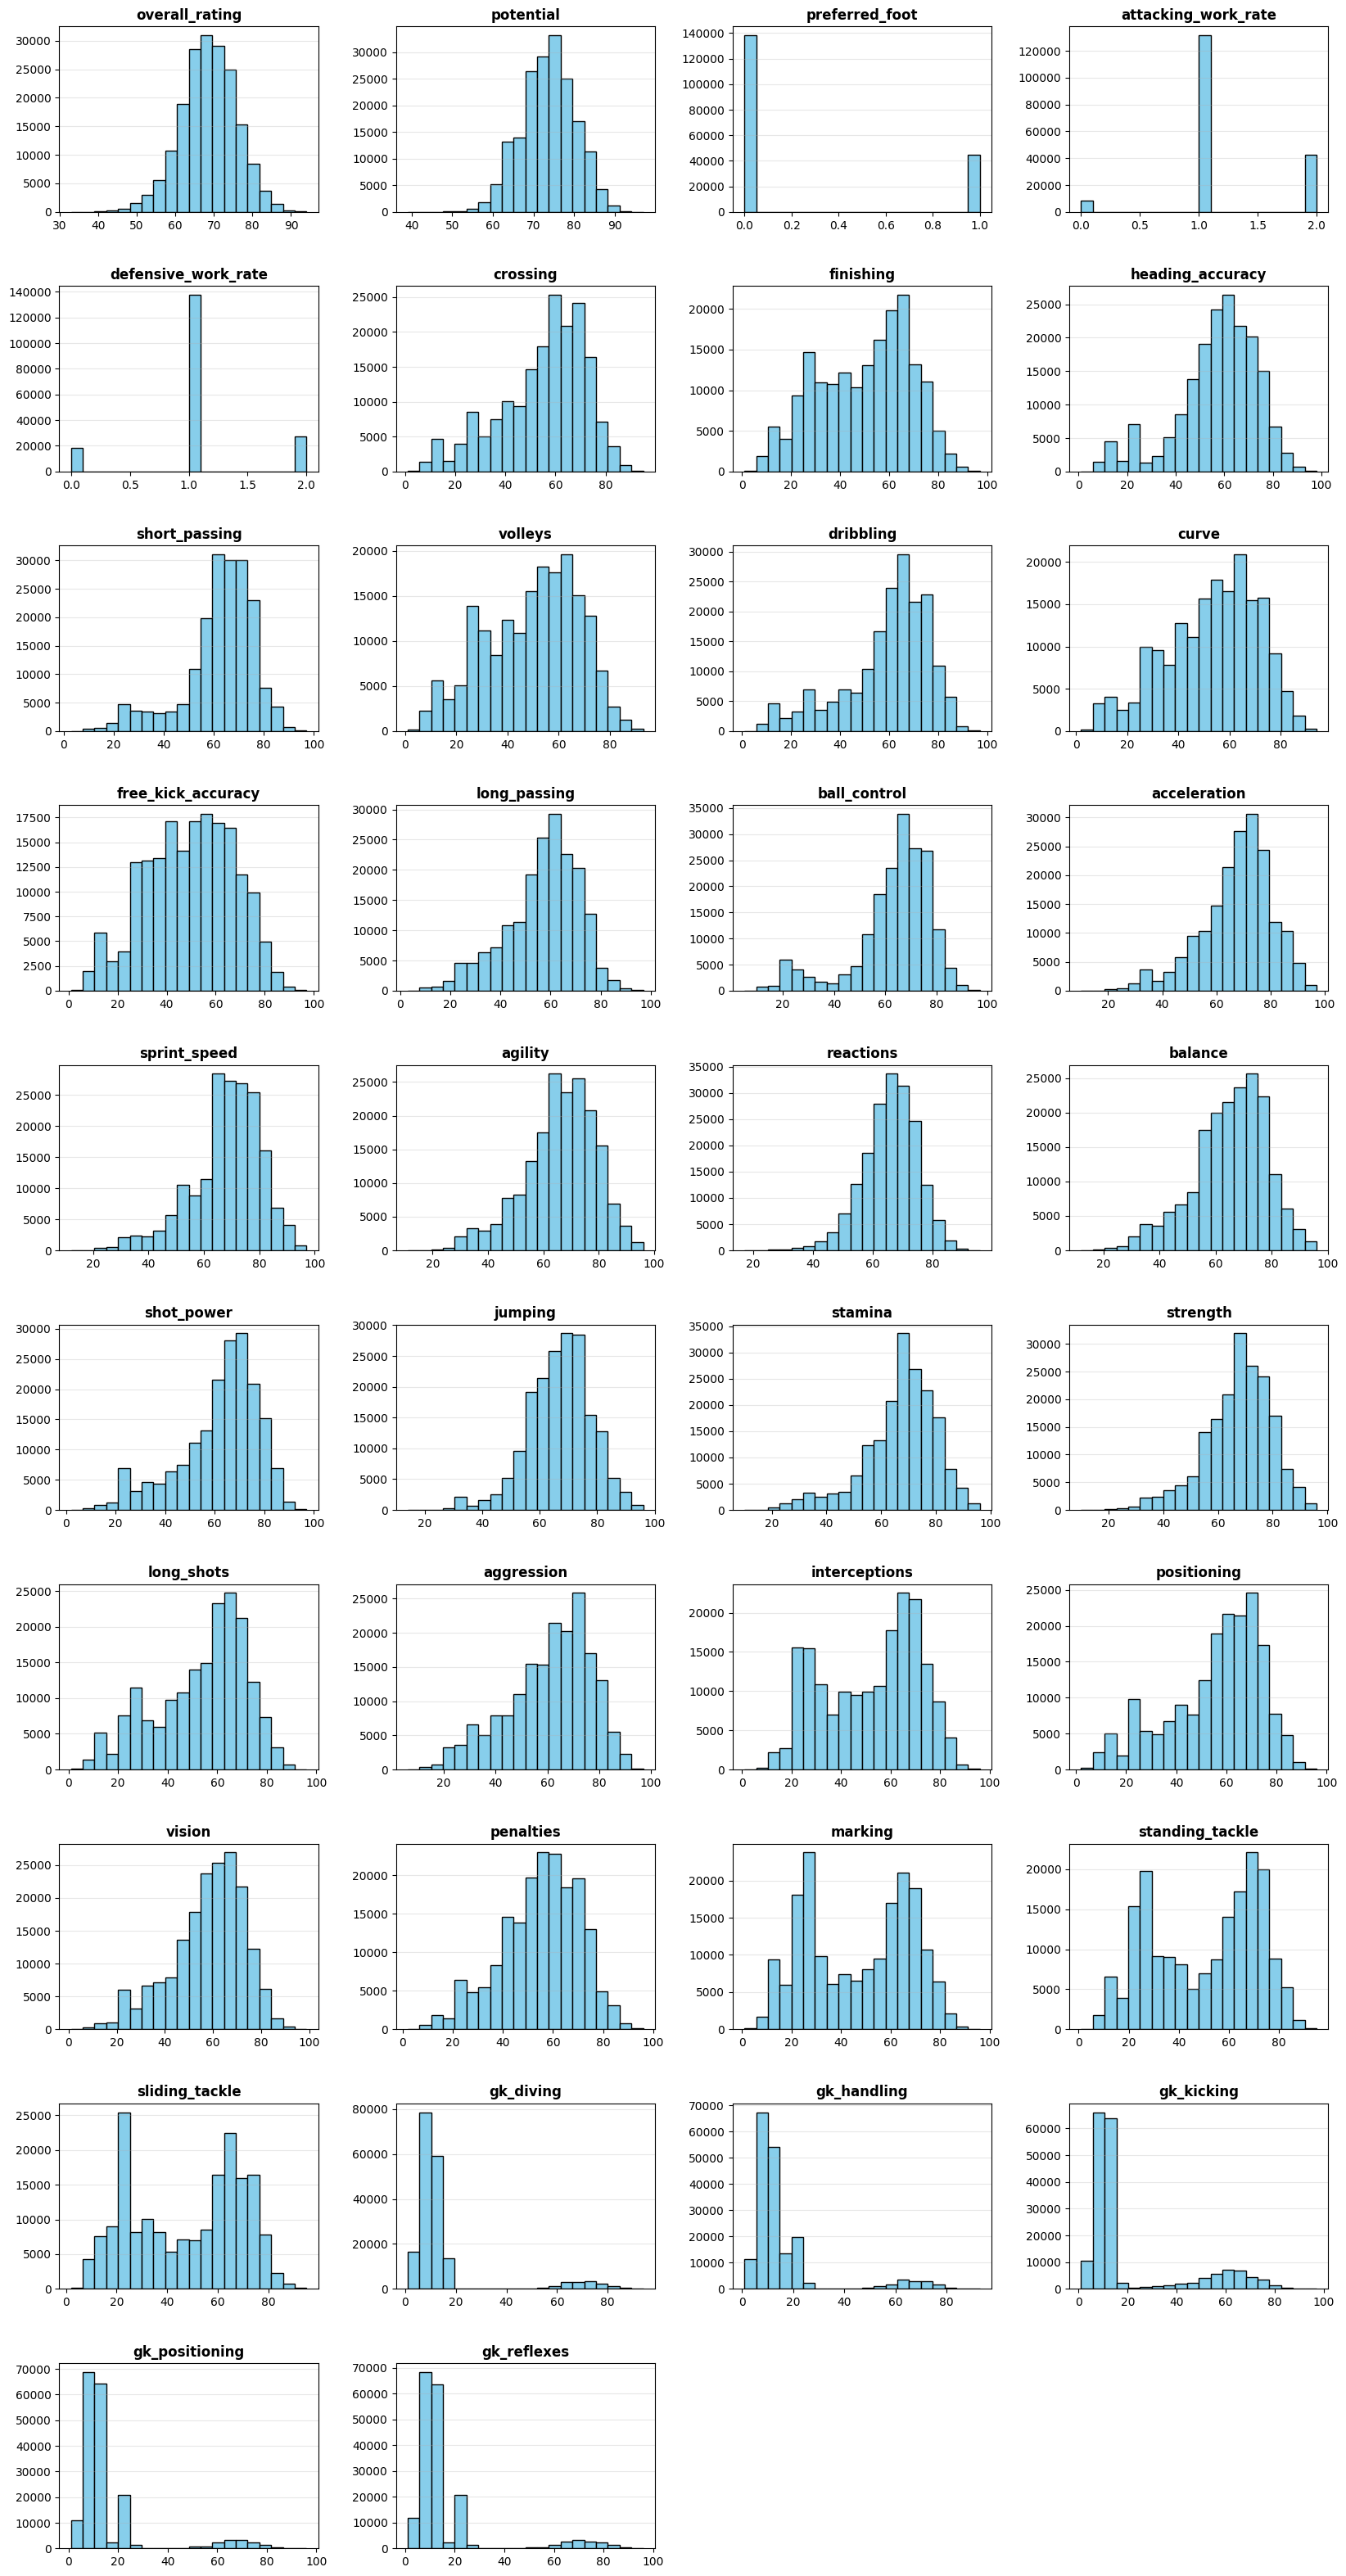

In [15]:
n_cols = len(cols_to_impute)
n_rows = math.ceil(n_cols / 4)

# Create the figure
fig, axes = plt.subplots(nrows=n_rows, ncols=4, figsize=(20, n_rows * 4))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

# Flatten axes for easy iteration
axes_flat = axes.flatten()

for i, col in enumerate(cols_to_impute):
    ax = axes_flat[i]
    ax.hist(df_player[col].dropna(), bins=20, color="skyblue", edgecolor="black")
    ax.set_title(col, fontsize=12, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)

# Remove unused subplots if 38 doesn't fill the grid (e.g., if you have 40 slots)
for j in range(i + 1, len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.show()

## Team

In [16]:
df_team = pd.merge(left=df_team_attributes, right=df_team, on="team_api_id")

In [17]:
df_team = df_team.drop(columns=["id_y", "team_fifa_api_id_y"])
df_team = df_team.rename(
    columns={"id_x": "id", "team_fifa_api_id_x": "team_fifa_api_id"}
)

In [18]:
df_team.head()

,id,team_fifa_api_id,team_api_id,date,buildUpPlaySpeed,buildUpPlaySpeedClass,buildUpPlayDribbling,buildUpPlayDribblingClass,buildUpPlayPassing,buildUpPlayPassingClass,...,chanceCreationPositioningClass,defencePressure,defencePressureClass,defenceAggression,defenceAggressionClass,defenceTeamWidth,defenceTeamWidthClass,defenceDefenderLineClass,team_long_name,team_short_name
0,1,434,9930,2010-02-22 00:00:00,60,Balanced,NaN,Little,50,Mixed,...,Organised,50,Medium,55,Press,45,Normal,Cover,FC Aarau,AAR
1,2,434,9930,2014-09-19 00:00:00,52,Balanced,48.0,Normal,56,Mixed,...,Organised,47,Medium,44,Press,54,Normal,Cover,FC Aarau,AAR
2,3,434,9930,2015-09-10 00:00:00,47,Balanced,41.0,Normal,54,Mixed,...,Organised,47,Medium,44,Press,54,Normal,Cover,FC Aarau,AAR
3,4,77,8485,2010-02-22 00:00:00,70,Fast,NaN,Little,70,Long,...,Organised,60,Medium,70,Double,70,Wide,Cover,Aberdeen,ABE
4,5,77,8485,2011-02-22 00:00:00,47,Balanced,NaN,Little,52,Mixed,...,Organised,47,Medium,47,Press,52,Normal,Cover,Aberdeen,ABE


In [19]:
df_team.info()

<class 'pandas.DataFrame'>
RangeIndex: 1458 entries, 0 to 1457
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              1458 non-null   int64  
 1   team_fifa_api_id                1458 non-null   int64  
 2   team_api_id                     1458 non-null   int64  
 3   date                            1458 non-null   str    
 4   buildUpPlaySpeed                1458 non-null   int64  
 5   buildUpPlaySpeedClass           1458 non-null   str    
 6   buildUpPlayDribbling            489 non-null    float64
 7   buildUpPlayDribblingClass       1458 non-null   str    
 8   buildUpPlayPassing              1458 non-null   int64  
 9   buildUpPlayPassingClass         1458 non-null   str    
 10  buildUpPlayPositioningClass     1458 non-null   str    
 11  chanceCreationPassing           1458 non-null   int64  
 12  chanceCreationPassingClass      1458 non-null

In [20]:
df_team.describe()

,id,team_fifa_api_id,team_api_id,buildUpPlaySpeed,buildUpPlayDribbling,buildUpPlayPassing,chanceCreationPassing,chanceCreationCrossing,chanceCreationShooting,defencePressure,defenceAggression,defenceTeamWidth
count,1458.000000,1458.000000,1458.000000,1458.000000,489.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000,1458.000000
mean,729.500000,17706.982167,9995.727023,52.462277,48.607362,48.490398,52.165295,53.731824,53.969136,46.017147,49.251029,52.185871
std,421.032659,39179.857739,13264.869900,11.545869,9.678290,10.896101,10.360793,11.086796,10.327566,10.227225,9.738028,9.574712
min,1.000000,1.000000,1601.000000,20.000000,24.000000,20.000000,21.000000,20.000000,22.000000,23.000000,24.000000,29.000000
25%,365.250000,110.000000,8457.750000,45.000000,42.000000,40.000000,46.000000,47.000000,48.000000,39.000000,44.000000,47.000000
50%,729.500000,485.000000,8674.000000,52.000000,49.000000,50.000000,52.000000,53.000000,53.000000,45.000000,48.000000,52.000000
75%,1093.750000,1900.000000,9904.000000,62.000000,55.000000,55.000000,59.000000,62.000000,61.000000,51.000000,55.000000,58.000000
max,1458.000000,112513.000000,274581.000000,80.000000,77.000000,80.000000,80.000000,80.000000,80.000000,72.000000,72.000000,73.000000


In [21]:
df_team["date"] = pd.to_datetime(df_team["date"]).dt.normalize()

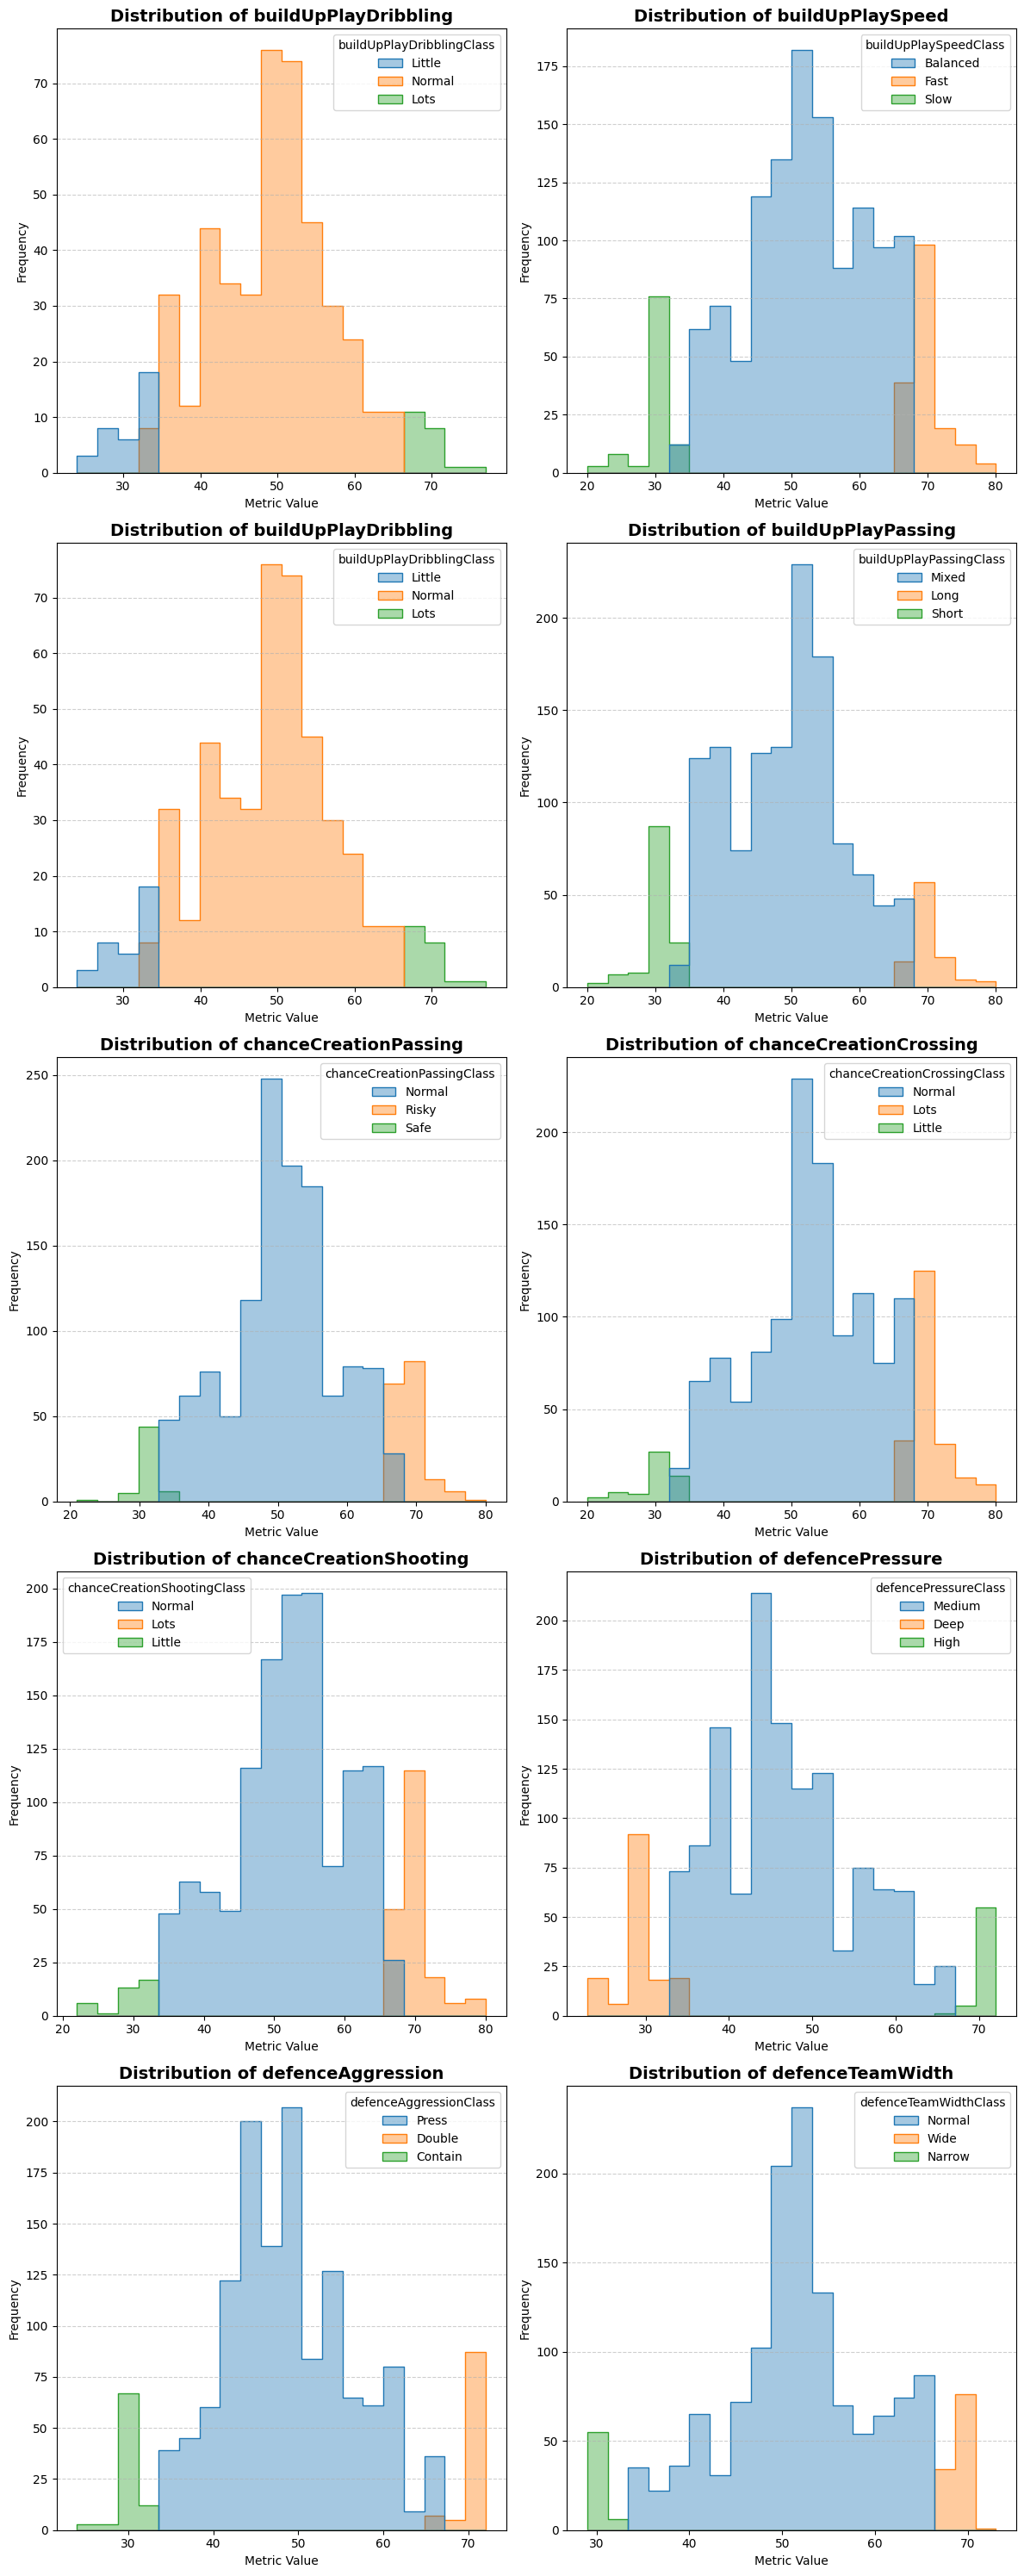

In [22]:
class_cols = [
    "buildUpPlayDribblingClass",
    "buildUpPlaySpeedClass",
    "buildUpPlayDribblingClass",
    "buildUpPlayPassingClass",
    "chanceCreationPassingClass",
    "chanceCreationCrossingClass",
    "chanceCreationShootingClass",
    "defencePressureClass",
    "defenceAggressionClass",
    "defenceTeamWidthClass",
]

# 2. Setup the 3x3 subplot grid
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 30))
axes = axes.flatten()  # Flatten to 1D array for easy looping

# 3. Iterate and plot
for i, cls_col in enumerate(class_cols):
    val_col = cls_col.replace("Class", "")  # e.g. 'buildUpPlaySpeed'

    # Use seaborn to split the histogram by the Class column
    sns.histplot(
        data=df_team,
        x=val_col,
        hue=cls_col,
        ax=axes[i],
        element="step",  # 'step' makes overlapping distributions easier to see
        palette="tab10",  # Clear categorical color palette
        alpha=0.4,
        bins=20,
    )

    # Formatting
    axes[i].set_title(f"Distribution of {val_col}", fontsize=14, fontweight="bold")
    axes[i].set_xlabel("Metric Value")
    axes[i].set_ylabel("Frequency")
    axes[i].grid(axis="y", linestyle="--", alpha=0.6)

# 4. Final Layout Adjustment
plt.tight_layout()
plt.show()

$\Rightarrow$ Just keep the numerical representations since the "Class" doesn't bring any value

In [23]:
df_team["buildUpPlayDribbling"] = df_team["buildUpPlayDribbling"].fillna(
    df_team.groupby("buildUpPlayDribblingClass")["buildUpPlayDribbling"].transform(
        "mean"
    )
)

In [24]:
df_team = df_team.drop(
    columns=[
        "buildUpPlaySpeedClass",
        "buildUpPlayDribblingClass",
        "buildUpPlayPassingClass",
        "chanceCreationPassingClass",
        "chanceCreationCrossingClass",
        "chanceCreationShootingClass",
        "defencePressureClass",
        "defenceAggressionClass",
        "defenceTeamWidthClass",
    ]
)

In [25]:
df_team.info()

<class 'pandas.DataFrame'>
RangeIndex: 1458 entries, 0 to 1457
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              1458 non-null   int64         
 1   team_fifa_api_id                1458 non-null   int64         
 2   team_api_id                     1458 non-null   int64         
 3   date                            1458 non-null   datetime64[us]
 4   buildUpPlaySpeed                1458 non-null   int64         
 5   buildUpPlayDribbling            1458 non-null   float64       
 6   buildUpPlayPassing              1458 non-null   int64         
 7   buildUpPlayPositioningClass     1458 non-null   str           
 8   chanceCreationPassing           1458 non-null   int64         
 9   chanceCreationCrossing          1458 non-null   int64         
 10  chanceCreationShooting          1458 non-null   int64         
 11  chanceCreationP

In [26]:
df_team[
    [
        "buildUpPlayPositioningClass",
        "chanceCreationPositioningClass",
        "defenceDefenderLineClass",
    ]
].value_counts()

buildUpPlayPositioningClass  chanceCreationPositioningClass  defenceDefenderLineClass
Organised                    Organised                       Cover                       1215
                             Free Form                       Cover                         95
                             Organised                       Offside Trap                  63
Free Form                    Free Form                       Cover                         28
                             Organised                       Cover                         24
                             Free Form                       Offside Trap                  13
Organised                    Free Form                       Offside Trap                  13
Free Form                    Organised                       Offside Trap                   7
Name: count, dtype: int64

In [27]:
df_team["buildUpPlayPositioningClass"].value_counts()

buildUpPlayPositioningClass
Organised    1386
Free Form      72
Name: count, dtype: int64

In [28]:
df_team["buildUpPlayPositioningClass"] = df_team["buildUpPlayPositioningClass"].map(
    {"Organised": 0, "Free Form": 1}
)

In [29]:
df_team["chanceCreationPositioningClass"].value_counts()

chanceCreationPositioningClass
Organised    1309
Free Form     149
Name: count, dtype: int64

In [30]:
df_team["chanceCreationPositioningClass"] = df_team[
    "chanceCreationPositioningClass"
].map({"Organised": 0, "Free Form": 1})

In [31]:
df_team["defenceDefenderLineClass"].value_counts()

defenceDefenderLineClass
Cover           1362
Offside Trap      96
Name: count, dtype: int64

In [32]:
df_team["defenceDefenderLineClass"] = df_team["defenceDefenderLineClass"].map(
    {"Cover": 0, "Offside Trap": 1}
)

In [33]:
df_team["team_api_id"].value_counts()

team_api_id
8485      6
8576      6
8564      6
10215     6
10217     6
         ..
274581    1
8242      1
6547      1
9999      1
8614      1
Name: count, Length: 288, dtype: int64

In [34]:
df_team.info()

<class 'pandas.DataFrame'>
RangeIndex: 1458 entries, 0 to 1457
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              1458 non-null   int64         
 1   team_fifa_api_id                1458 non-null   int64         
 2   team_api_id                     1458 non-null   int64         
 3   date                            1458 non-null   datetime64[us]
 4   buildUpPlaySpeed                1458 non-null   int64         
 5   buildUpPlayDribbling            1458 non-null   float64       
 6   buildUpPlayPassing              1458 non-null   int64         
 7   buildUpPlayPositioningClass     1458 non-null   int64         
 8   chanceCreationPassing           1458 non-null   int64         
 9   chanceCreationCrossing          1458 non-null   int64         
 10  chanceCreationShooting          1458 non-null   int64         
 11  chanceCreationP

## Match

In [58]:
df_match = df_match.drop(
    columns=[
        "country_id",
        "league_id",
        "season",
        "stage",
        "goal",
        "shoton",
        "shotoff",
        "foulcommit",
        "card",
        "cross",
        "corner",
        "possession",
        "B365H",
        "B365D",
        "B365D",
        "B365H",
        "B365D",
        "B365A",
        "BWH",
        "BWD",
        "BWA",
        "IWH",
        "IWD",
        "IWA",
        "LBH",
        "LBD",
        "LBA",
        "PSH",
        "PSD",
        "PSA",
        "WHH",
        "WHD",
        "WHA",
        "SJH",
        "SJD",
        "SJA",
        "VCH",
        "VCD",
        "VCA",
        "GBH",
        "GBD",
        "GBA",
        "BSH",
        "BSD",
        "BSA",
    ]
)

In [61]:
df_match = df_match.dropna()

In [110]:
df_match["date"] = pd.to_datetime(df_match["date"])

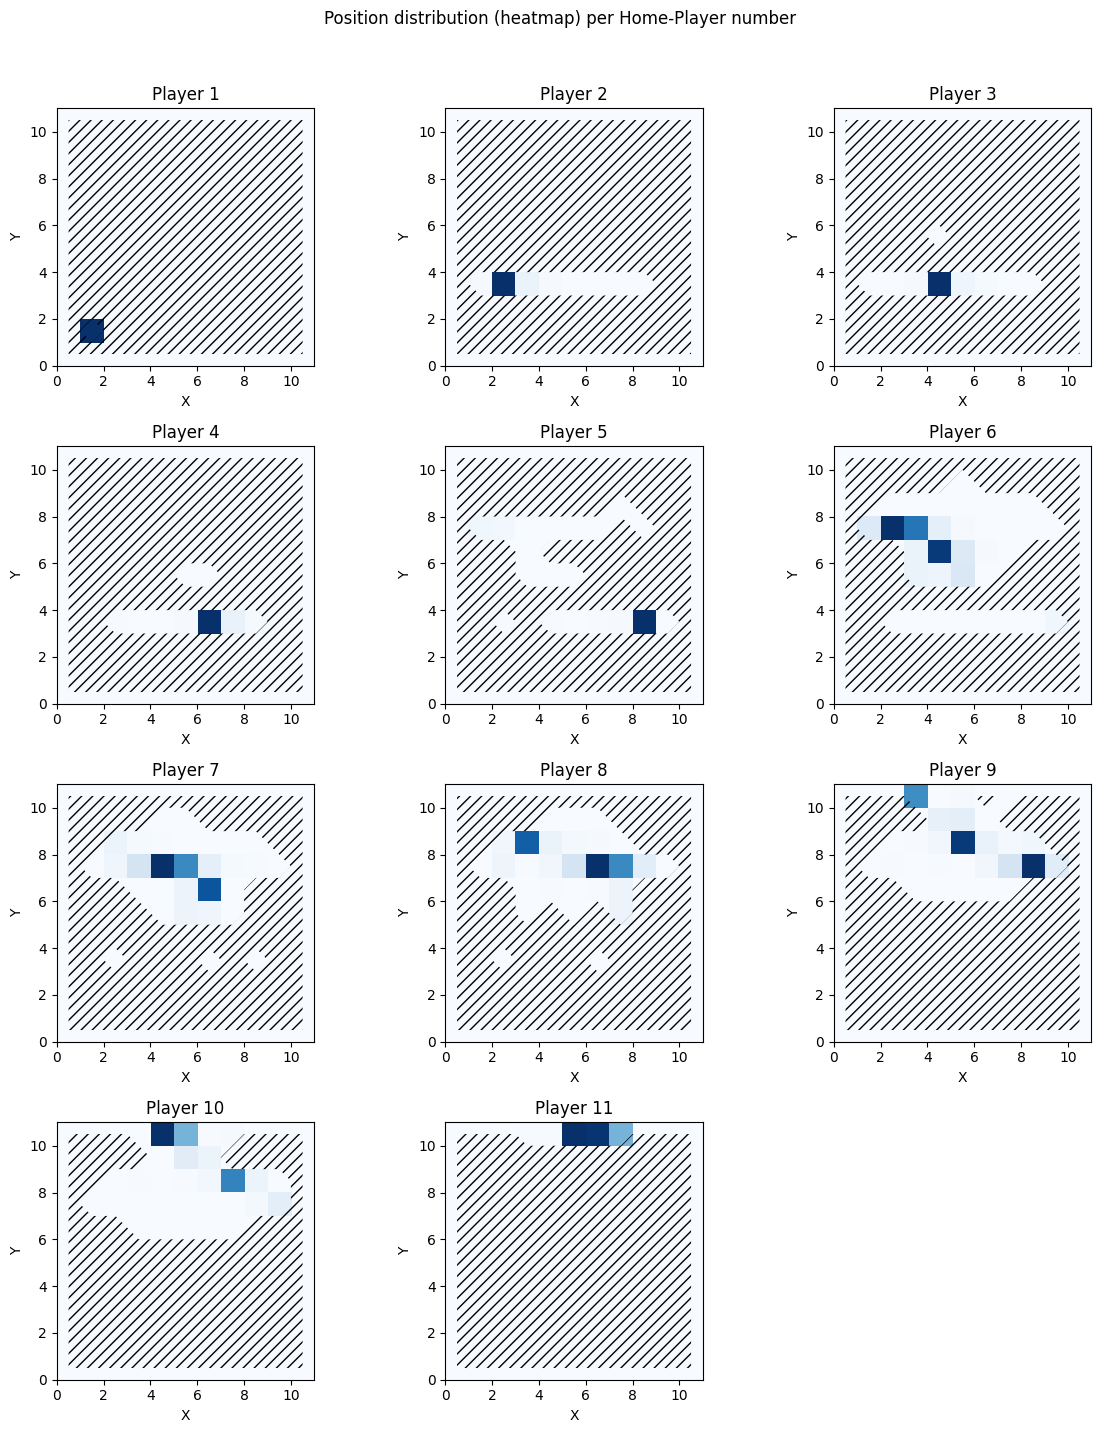

In [ ]:
bins = 11
fig, axes = plt.subplots(4, 3, figsize=(12, 14))
axes = axes.flatten()

for i in range(1, 12):
    ax = axes[i - 1]
    x_col = f"home_player_X{i}"
    y_col = f"home_player_Y{i}"
    xy = df_match[[x_col, y_col]].dropna()
    x_vals = xy[x_col].to_numpy()
    y_vals = xy[y_col].to_numpy()
    H, xedges, yedges = np.histogram2d(
        x_vals, y_vals, bins=bins, range=[[0, 11], [0, 11]]
    )
    ax.imshow(
        H.T,
        extent=[0, 11, 0, 11],
        origin="lower",
        aspect="equal",
        cmap="Blues",
        interpolation="nearest",
    )
    # Schraffur für Bereiche mit 0 Vorkommen
    x_centers = (xedges[:-1] + xedges[1:]) / 2
    y_centers = (yedges[:-1] + yedges[1:]) / 2
    X, Y = np.meshgrid(x_centers, y_centers)
    Z = np.where(H.T == 0, 1.0, 0.0)
    ax.contourf(X, Y, Z, levels=[0.5, 1.5], hatches=["///"], colors="none")
    ax.set_xlim(0, 11)
    ax.set_ylim(0, 11)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_title(f"Player {i}")

# Hide the 12th subplot
axes[11].set_visible(False)
plt.suptitle("Position distribution (heatmap) per Home-Player number", y=1.02)
plt.tight_layout()
plt.show()

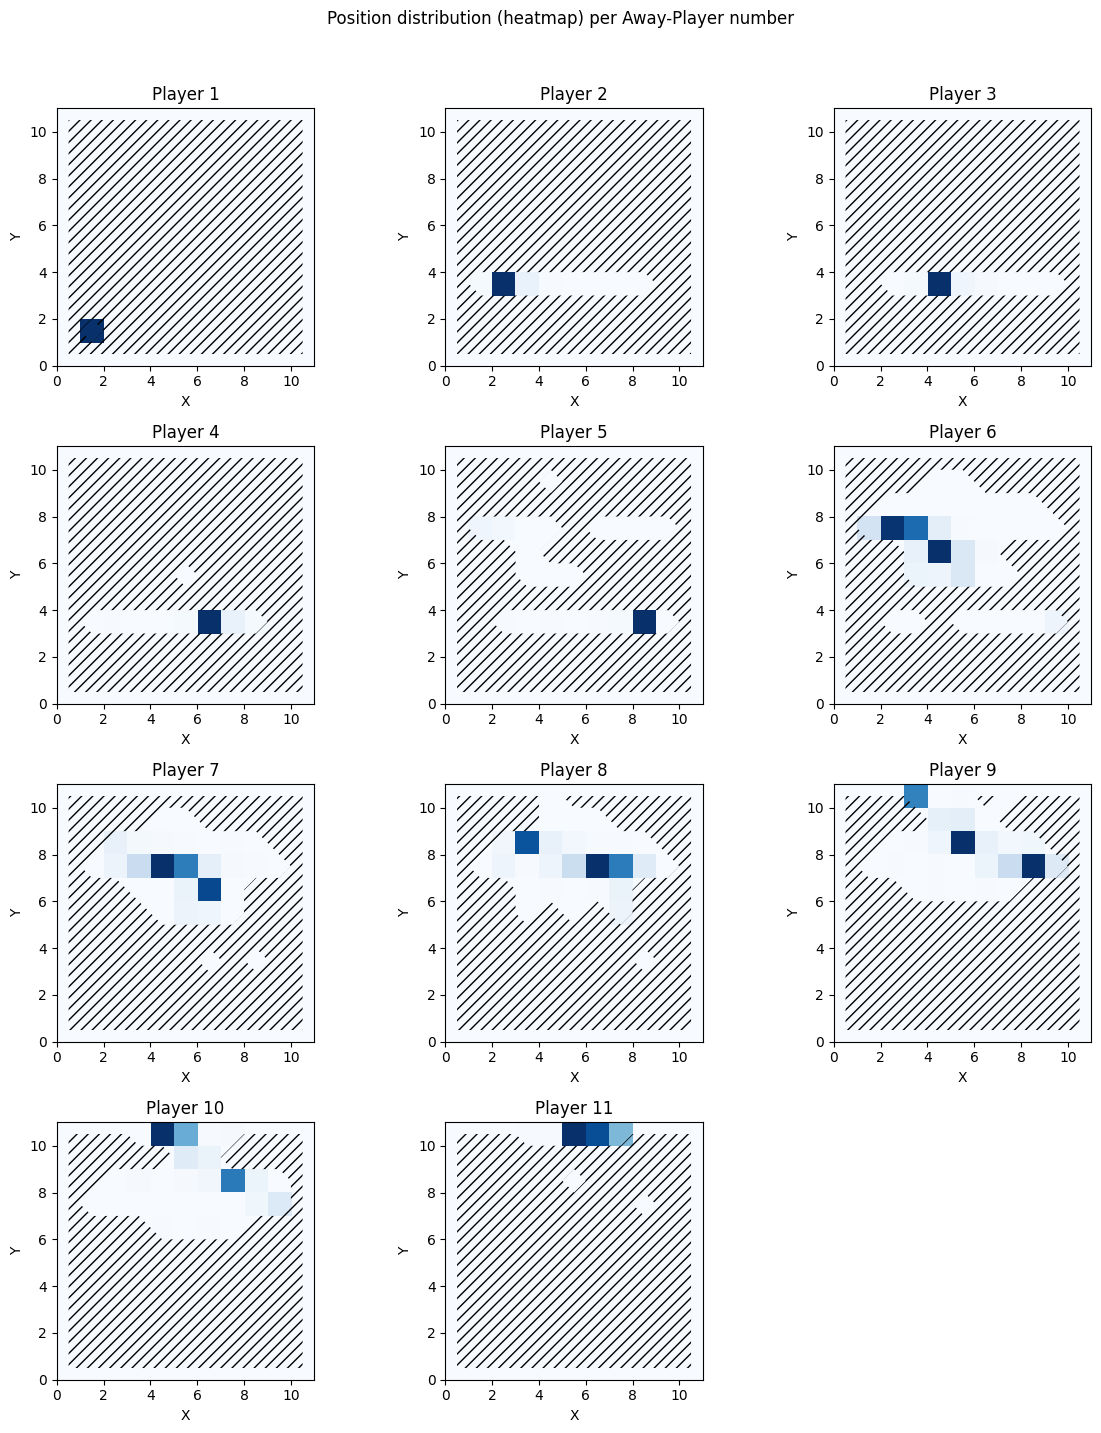

In [90]:
# 11 subplots: position distribution as heatmap per player number (1–11)
bins = 11
fig, axes = plt.subplots(4, 3, figsize=(12, 14))
axes = axes.flatten()

for i in range(1, 12):
    ax = axes[i - 1]
    x_col = f"away_player_X{i}"
    y_col = f"away_player_Y{i}"
    xy = df_match[[x_col, y_col]].dropna()
    x_vals = xy[x_col].to_numpy()
    y_vals = xy[y_col].to_numpy()
    H, xedges, yedges = np.histogram2d(
        x_vals, y_vals, bins=bins, range=[[0, 11], [0, 11]]
    )
    ax.imshow(
        H.T,
        extent=[0, 11, 0, 11],
        origin="lower",
        aspect="equal",
        cmap="Blues",
        interpolation="nearest",
    )
    # Schraffur für Bereiche mit 0 Vorkommen
    x_centers = (xedges[:-1] + xedges[1:]) / 2
    y_centers = (yedges[:-1] + yedges[1:]) / 2
    X, Y = np.meshgrid(x_centers, y_centers)
    Z = np.where(H.T == 0, 1.0, 0.0)
    ax.contourf(X, Y, Z, levels=[0.5, 1.5], hatches=["///"], colors="none")
    ax.set_xlim(0, 11)
    ax.set_ylim(0, 11)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_title(f"Player {i}")

# Hide the 12th subplot
axes[11].set_visible(False)
plt.suptitle("Position distribution (heatmap) per Away-Player number", y=1.02)
plt.tight_layout()
plt.show()

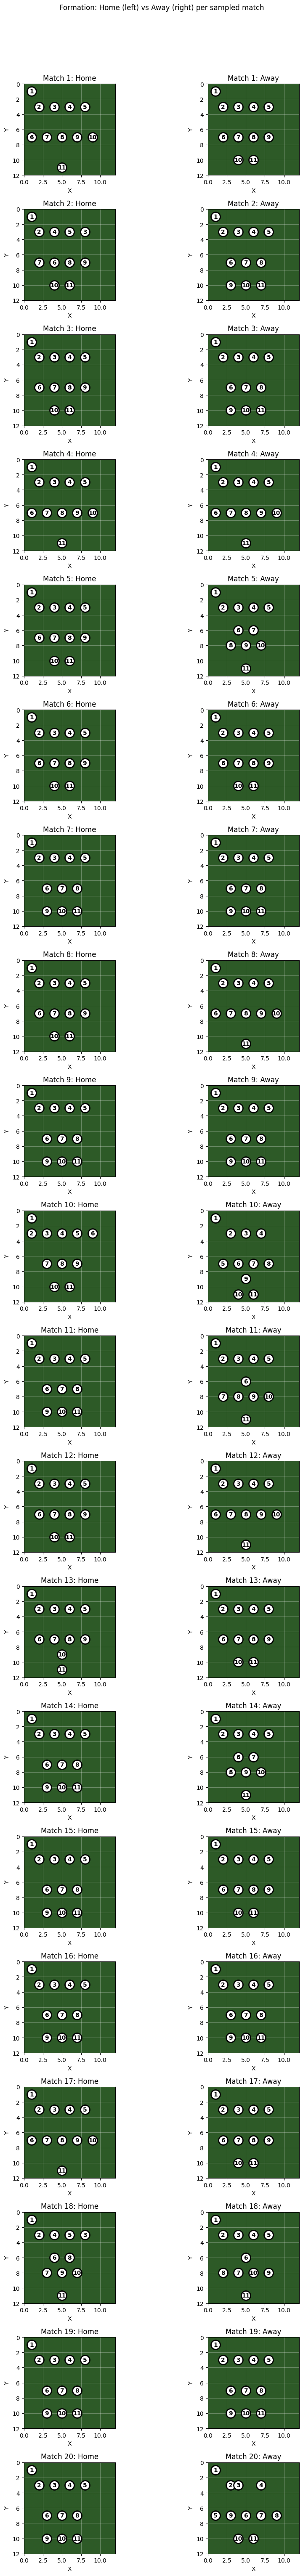

In [96]:
n = 20  # number of matches to sample
rng = np.random.default_rng(42)
sample_idx = rng.choice(df_match.index, size=min(n, len(df_match)), replace=False)
df_sample = df_match.loc[sample_idx]

fig, axes = plt.subplots(n, 2, figsize=(10, 3 * n))
if n == 1:
    axes = axes.reshape(1, -1)

for i, (idx, row) in enumerate(df_sample.iterrows()):
    # Home team (left column)
    ax_h = axes[i, 0]
    for j in range(1, 12):
        x, y = row[f"home_player_X{j}"], row[f"home_player_Y{j}"]
        if pd.notna(x) and pd.notna(y):
            ax_h.scatter(
                x, y, s=250, c="white", edgecolors="black", linewidths=2, zorder=2
            )
            ax_h.annotate(
                str(j),
                (x, y),
                ha="center",
                va="center",
                fontsize=10,
                fontweight="bold",
                zorder=3,
            )
    ax_h.set_xlim(0, 12)
    ax_h.set_ylim(0, 12)
    ax_h.invert_yaxis()
    ax_h.set_aspect("equal")
    ax_h.set_facecolor("#2d5a27")
    ax_h.grid(True, color="white", alpha=0.3)
    ax_h.set_title(f"Match {i + 1}: Home")
    ax_h.set_xlabel("X")
    ax_h.set_ylabel("Y")

    # Away team (right column)
    ax_a = axes[i, 1]
    for j in range(1, 12):
        x, y = row[f"away_player_X{j}"], row[f"away_player_Y{j}"]
        if pd.notna(x) and pd.notna(y):
            ax_a.scatter(
                x, y, s=250, c="white", edgecolors="black", linewidths=2, zorder=2
            )
            ax_a.annotate(
                str(j),
                (x, y),
                ha="center",
                va="center",
                fontsize=10,
                fontweight="bold",
                zorder=3,
            )
    ax_a.set_xlim(0, 12)
    ax_a.set_ylim(0, 12)
    ax_a.invert_yaxis()
    ax_a.set_aspect("equal")
    ax_a.set_facecolor("#2d5a27")
    ax_a.grid(True, color="white", alpha=0.3)
    ax_a.set_title(f"Match {i + 1}: Away")
    ax_a.set_xlabel("X")
    ax_a.set_ylabel("Y")

plt.suptitle("Formation: Home (left) vs Away (right) per sampled match", y=1.02)
plt.tight_layout()
plt.show()

In [104]:
def get_formation_set(row, prefix):
    """Extract formation as frozenset of (x,y) positions so player order doesn't matter."""
    positions = []
    for j in range(1, 12):
        x = row[f"{prefix}_player_X{j}"]
        y = row[f"{prefix}_player_Y{j}"]
        positions.append((int(round(x)), int(round(y))))
    return frozenset(positions)


def formation_key_to_str(key):
    """Single string representation for (home_set, away_set) for the output column."""
    home_set, away_set = key
    home_str = "|".join(f"{x},{y}" for x, y in sorted(home_set))
    away_str = "|".join(f"{x},{y}" for x, y in sorted(away_set))
    return f"home[{home_str}] away[{away_str}]"


# One formation = (home positions set, away positions set); order of players ignored
formation_keys = df_match.apply(
    lambda row: (get_formation_set(row, "home"), get_formation_set(row, "away")),
    axis=1,
)
counts = formation_keys.value_counts().reset_index()
counts.columns = ["formation_key", "count"]
counts["formation"] = counts["formation_key"].map(formation_key_to_str)
df_formation_counts = (
    counts[["formation", "count"]]
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)
print(f"There are {len(df_formation_counts)} unique formations in the dataset.")

There are 592 unique formations in the dataset.


In [112]:
conn = sqlite3.connect(db_path.as_posix())

df_player.to_sql(
    "Player_Cleaned",
    conn,
    if_exists="replace",
    index=False,
)

df_team.to_sql(
    "Team_Cleaned",
    conn,
    if_exists="replace",
    index=False,
)

df_match.to_sql(
    "Match_Cleaned",
    conn,
    if_exists="replace",
    index=False,
)

conn.close()